In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot
import text_analyzer
import correlation_analyzer as ca

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/META.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,META,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,META,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,META,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,META,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,META,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [4]:
preprocesser.explore_data(data)

Shape of the data: (2923, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2923 entries, 0 to 2922
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  2923 non-null   object 
 1   Date    2923 non-null   object 
 2   Close   2923 non-null   float64
 3   High    2923 non-null   float64
 4   Low     2923 non-null   float64
 5   Open    2923 non-null   float64
 6   Volume  2923 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 160.0+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2012-05-18,META,41.792356,44.724282,37.767172,37.995762,573576400
2012-05-21,META,36.306177,36.435382,32.797807,33.821495,168192700
2012-05-22,META,32.410203,33.384198,30.750434,30.810066,101786600
2012-05-23,META,31.177799,32.300874,31.167860,31.803938,73600000
2012-05-24,META,32.748117,33.006523,31.575347,32.827625,50237200


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,2923.000000,2923.000000,2923.000000,2923.000000,2.923000e+03
mean,156.653626,158.690484,154.685098,156.727440,3.060615e+07
std,90.308834,91.470736,89.222981,90.368766,2.637157e+07
min,17.969224,18.158061,17.442471,17.621368,5.467500e+06
25%,80.275126,80.970839,79.663892,80.275124,1.633730e+07
50%,152.698669,154.636700,150.730785,152.579376,2.295390e+07
75%,202.963782,206.372783,200.548679,203.550171,3.522740e+07
max,379.341431,381.975166,376.488998,379.838379,5.735764e+08


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,META,353.401377,355.011477,349.068105,351.224823,11772800,332.302945,323.317843,332.302945,323.317843,67.333885,6.945367,4.729907,2.215461
2023-12-26,META,352.814999,354.792827,351.284456,352.655975,9898600,333.303278,324.115724,333.303278,324.115724,68.187000,7.436800,5.271285,2.165514
2023-12-27,META,353.888347,356.800387,353.132994,355.637543,13207900,334.239505,324.844828,334.239505,324.844828,69.947874,7.974921,5.812012,2.162908
2023-12-28,META,357.496184,359.682686,355.617749,356.124634,11798800,335.537503,325.527023,335.537503,325.527023,70.237702,8.344500,6.318510,2.025990
2023-12-29,META,356.790470,357.794292,349.664418,351.791290,14987100,336.869788,326.262290,336.869788,326.262290,64.296803,8.193282,6.693464,1.499818


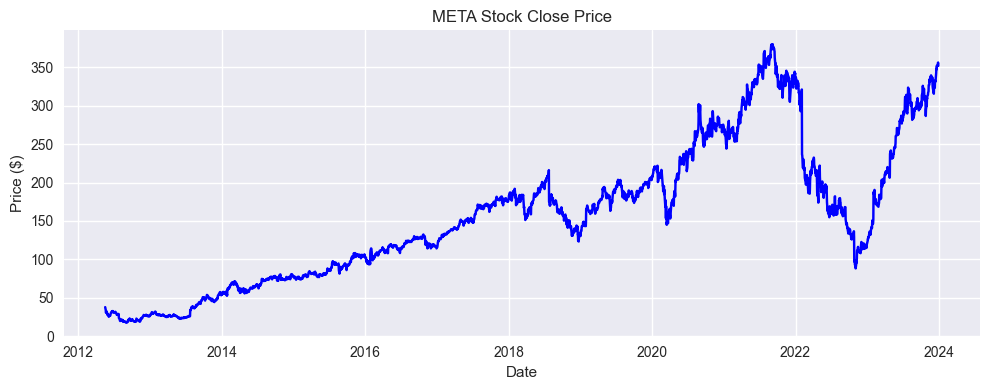

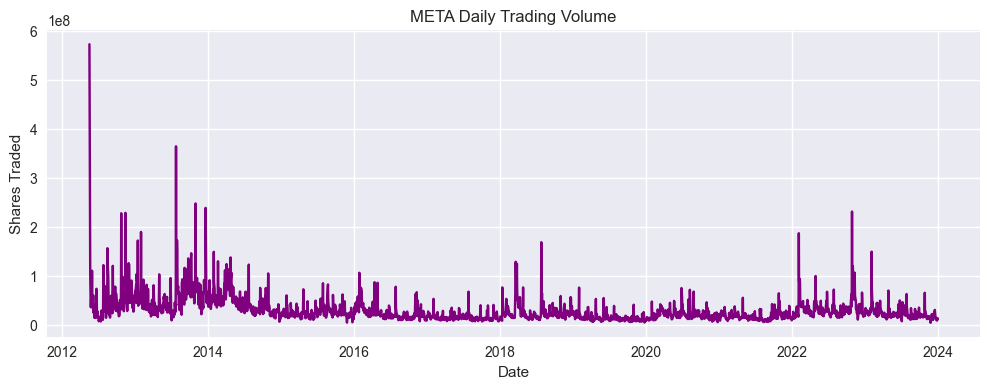

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)

### Correlation Analysis

In [16]:
headline_data = util.load_data('../../data/cleaned/cleaned_news_data.csv')

After loading the data, we filter the headlines by stock. And then normalize the dates as we did previously.

In [17]:
headline_data = stockutils.filter_data_by_stock(headline_data, 'FB')
preprocesser.convert_date_dtype(headline_data)
headline_data.head(5)

Converted 'date' dtype: datetime64[ns, UTC]


,headline,url,publisher,date,stock
473873,As Expected: Fed Keeps Rates Unchanged and For...,https://www.benzinga.com/news/20/06/16226512/a...,JJ Kinahan,2020-06-10 20:20:19+00:00,FB
473874,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 19:25:13+00:00,FB
473875,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,FB
473876,Big Tech Reaches New Record Heights At The Sto...,https://www.benzinga.com/news/20/06/16218615/b...,Neer Varshney,2020-06-10 04:52:01+00:00,FB
473877,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 04:28:00+00:00,FB


In [18]:
textanaysis = text_analyzer.TextAnalyzer

Here we only keep the relevant columns for the correlation analysis.

In [19]:
headline_with_sentiment = textanaysis.analyze_headline_sentiment(headline_data)
headline_with_sentiment['date'] = headline_with_sentiment ['date'].dt.date

headlines_with_sentiment= headline_with_sentiment[['date', 'headline', 'stock', 'sentiment', 'sentiment_score']].copy()

In [20]:
combined_data = stockutils.merge_sentiment_with_stock(headlines_with_sentiment, data)
combined_data.head()

,headline,stock,sentiment,sentiment_score,Close,Volume
date,,,,,,
2020-06-10,As Expected: Fed Keeps Rates Unchanged and For...,FB,neutral,0.0000,235.279572,20720700.0
2020-06-10,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",FB,neutral,0.0000,235.279572,20720700.0
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,FB,positive,0.5574,235.279572,20720700.0
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,FB,positive,0.0516,235.279572,20720700.0
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",FB,positive,0.7096,235.279572,20720700.0


Update all columns to be in lowercase.

In [21]:
combined_data_lowercase = stockutils.lowercase_columns(combined_data)
combined_data_lowercase.head(5)

,headline,stock,sentiment,sentiment_score,close,volume
date,,,,,,
2020-06-10,As Expected: Fed Keeps Rates Unchanged and For...,FB,neutral,0.0000,235.279572,20720700.0
2020-06-10,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",FB,neutral,0.0000,235.279572,20720700.0
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,FB,positive,0.5574,235.279572,20720700.0
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,FB,positive,0.0516,235.279572,20720700.0
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",FB,positive,0.7096,235.279572,20720700.0


#### Daily Returns

In [22]:
data_with_daily_returns = technical_indicators.calculate_daily_returns(combined_data_lowercase)
data_with_daily_returns.head()

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/stocks/../../scripts/stock_indicators.py:47: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,headline,stock,sentiment,sentiment_score,close,volume,daily_returns
date,,,,,,,
2020-06-10,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",FB,neutral,0.0000,235.279572,20720700.0,0.000000
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,FB,positive,0.5574,235.279572,20720700.0,0.000000
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,FB,positive,0.0516,235.279572,20720700.0,0.000000
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",FB,positive,0.7096,235.279572,20720700.0,0.000000
2020-06-09,Afternoon Market Stats in 5 Minutes,FB,neutral,0.0000,237.207687,27462900.0,0.008195


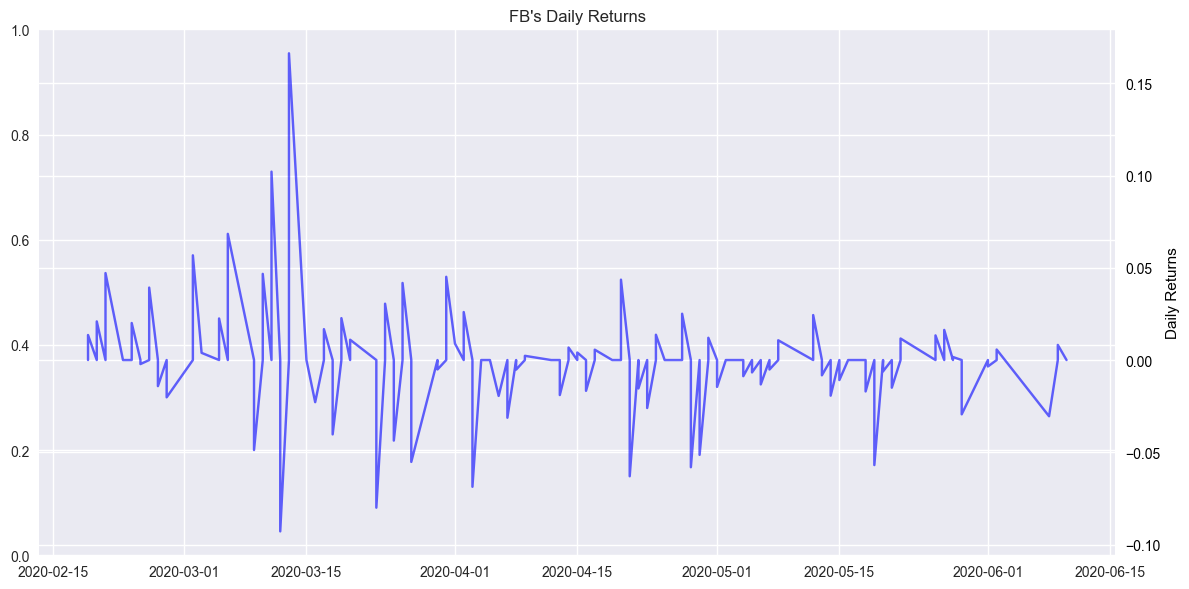

In [23]:
plotter.plot_daily_returns(data_with_daily_returns)

In [24]:
correlation_analysis = ca.CorrelationAnalysis

In [25]:
correlation_analysis.sentiment_correlation_analysis(data_with_daily_returns)

Correlation between sentiment_score and daily_returns is 0.0628
Correlation between sentiment_score and close is 0.0175


(np.float64(0.06283729494466755), np.float64(0.017527022718849358))

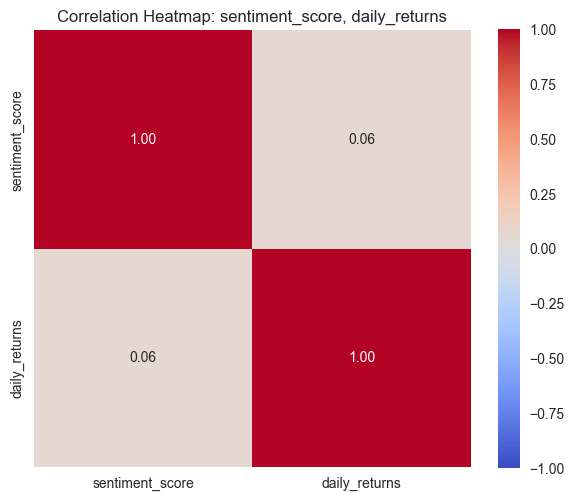

In [26]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns' ])

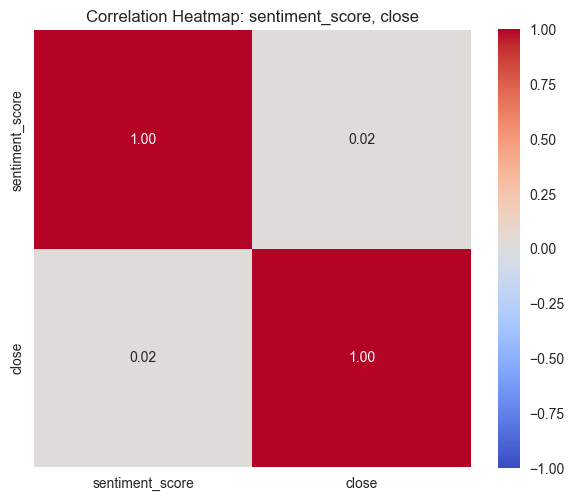

In [27]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'close' ])

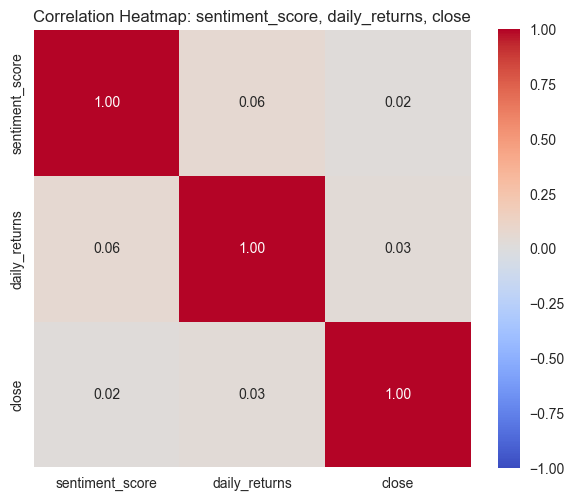

In [28]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close' ])

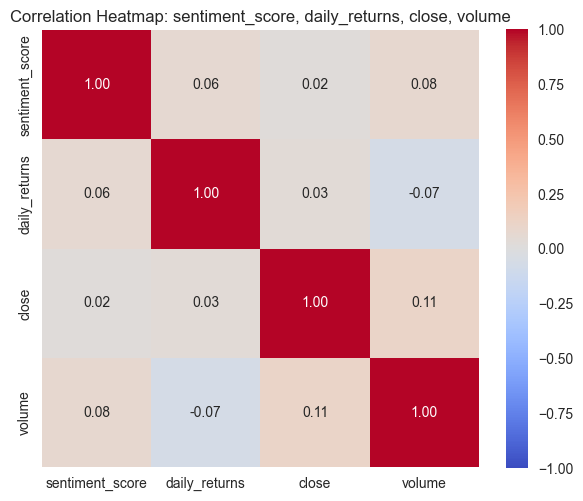

In [29]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close', 'volume' ])